# Ranked Founder Result Analysis

Link `ranked_founders.csv` with real company performance and visualize basic performance metrics for ranked founders.

## 1. Load ranked founders and real company data

We load:
- `xgboost/experiments/ranked_founders.csv` (founder ranking output)
- `xgboost/src/data/real/founder_experience.csv` (founder–company links)
- `xgboost/src/data/real/company_info.csv` (company-level performance).

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent

ranked_path = PROJECT_ROOT / "experiments" / "ranked_founders.csv"
real_root = PROJECT_ROOT / "src" / "data" / "real"
exp_path = real_root / "founder_experience.csv"
company_path = real_root / "company_info.csv"

ranked = pd.read_csv(ranked_path)
exp_real = pd.read_csv(exp_path)
company_real = pd.read_csv(company_path)

print("ranked_founders rows:", len(ranked))
print("unique ranked founders:", ranked["founder_id"].nunique())
print("real founder_experience rows:", len(exp_real))
print("real company_info rows:", len(company_real))


ranked_founders rows: 120
unique ranked founders: 120
real founder_experience rows: 1583
real company_info rows: 456


## 2. Join founders to company performance

We:
1. Strip the `/p/` prefix from `person_id` to match `founder_id`.
2. Join experiences to `company_info` on `company_id`.
3. Aggregate company `performance` per founder (mean, max, min, last).

In [6]:
# Map real founder IDs to the same format as ranked_founders.founder_id
exp_real["person_key"] = exp_real["person_id"].str.replace(r"^/p/", "", regex=True)

# Drop rows without company_id before joining to company performance
exp_nonnull = exp_real.dropna(subset=["company_id"]).copy()

merged = exp_nonnull.merge(company_real, on="company_id", how="left")
print("Merged experience+company rows:", len(merged))

# Keep only rows with a defined performance for aggregation
m_perf = merged[merged["performance"].notna()].copy()

# Use the `order` column to define the "last" company with performance per founder
m_perf["order_str"] = m_perf["order"].astype(str)
last_idx = m_perf.groupby("person_key")["order_str"].idxmax()
last_perf = (
    m_perf.loc[last_idx, ["person_key", "performance"]]
    .set_index("person_key")["performance"]
)

agg_perf = (
    m_perf.groupby("person_key")["performance"]
    .agg(["mean", "max", "min", "count"])
    .rename(columns={
        "mean": "perf_mean",
        "max": "perf_max",
        "min": "perf_min",
        "count": "perf_count",
    })
)
agg_perf["perf_last"] = last_perf

print("Founders with any performance data:", len(agg_perf))
agg_perf.head()


Merged experience+company rows: 886
Founders with any performance data: 75


,perf_mean,perf_max,perf_min,perf_count,perf_last
person_key,,,,,
SAZwAAgGChswGQoMGSoHAwoJAQsIFg==,0.000000,0.000000,0.000000,1,0.000000
SAZwAAgMFwkBMgsGDD4GGAoLNx8FOgM=,1.599971,1.599971,1.599971,4,1.599971
SAZwAAkCBA8AMgMOESoRCBkADAA=,1.204198,1.204198,1.204198,1,1.204198
SAZwAAkECAkcMg0SBDYRGw==,1.000000,1.000000,1.000000,2,1.000000
SAZwAggYDQkDMhYPFzc=,5.490081,5.669738,5.130766,3,5.669738


## 3. Attach performance metrics to ranked founders

Join the aggregated performance frame on `founder_id` and inspect coverage.

In [7]:
ranked_with_perf = ranked.merge(
    agg_perf, left_on="founder_id", right_index=True, how="left"
)

print("Ranked founders with any perf_count:", ranked_with_perf["perf_count"].notna().sum())
ranked_with_perf.head()


Ranked founders with any perf_count: 75


,founder_id,industry,score,rank,explanation,perf_mean,perf_max,perf_min,perf_count,perf_last
0,SAZwAAgMFwkBMgsGDD4GGAoLNx8FOgM=,Information Technology,0.375848,1,"Top factors: performance (-0.54), founder_perf...",1.599971,1.599971,1.599971,4.0,1.599971
1,SAZwFRMGAAYwHgQAHj4ABAcMCQE=,Information Technology,0.082479,2,"Top factors: performance (-0.62), education_ti...",1.599971,1.599971,1.599971,2.0,1.599971
2,SAZwBwQZAg0WMggGBDQbEhIEBg==,Information Technology,-0.003702,3,"Top factors: performance (-0.63), network_qual...",1.599971,1.599971,1.599971,4.0,1.599971
3,SAZwGQAZDjcHBAsDGz4GEgM=,Information Technology,-0.597027,4,"Top factors: performance (-1.26), education_ti...",2.074805,5.689736,0.000000,7.0,5.689736
4,SAZwBAQZFxEwBQQLEjoaAxI=,Information Technology,-0.636216,5,"Top factors: performance (-1.22), education_ti...",1.000000,1.000000,1.000000,1.0,1.000000


## 4. Visualize performance metrics for ranked founders

Plot simple histograms for mean, max, and last performance among founders that have performance data.

Number of ranked founders with performance metrics: 75


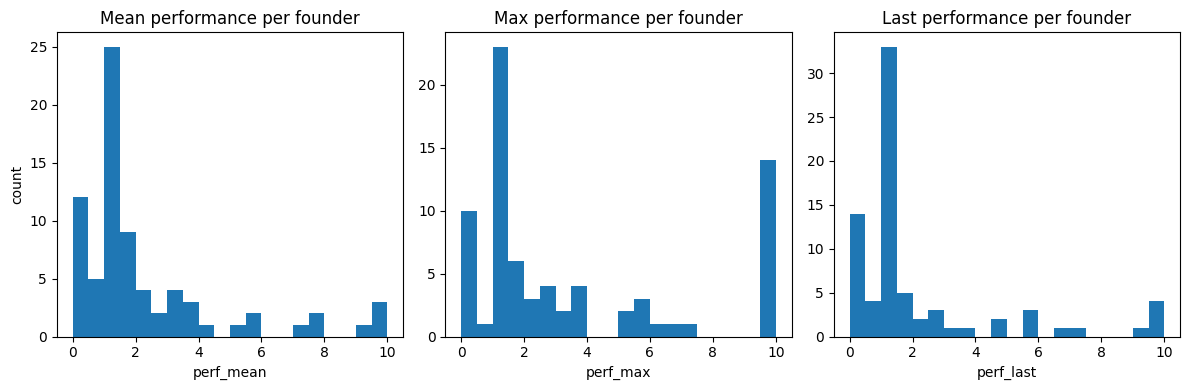

In [8]:
mask = ranked_with_perf["perf_count"].notna()
subset = ranked_with_perf[mask]
print("Number of ranked founders with performance metrics:", len(subset))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(subset["perf_mean"].dropna(), bins=20)
plt.title("Mean performance per founder")
plt.xlabel("perf_mean")
plt.ylabel("count")

plt.subplot(1, 3, 2)
plt.hist(subset["perf_max"].dropna(), bins=20)
plt.title("Max performance per founder")
plt.xlabel("perf_max")

plt.subplot(1, 3, 3)
plt.hist(subset["perf_last"].dropna(), bins=20)
plt.title("Last performance per founder")
plt.xlabel("perf_last")

plt.tight_layout()
plt.show()
